# Importing libraries

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cleaning the data for debt

In [19]:
filename_debt = 'new_debt_data.xlsx'

# removing 2 rows
debt = pd.read_excel(filename_debt, skiprows=2)

# removing 2 columns
debt = debt.iloc[:, 2:]

# renaming
debt.rename(columns = {'Unnamed: 2':'Countries'}, inplace=True)

# wide to long
debt_long = pd.melt(debt, id_vars=['Countries'], var_name='year', value_name='debt')
debt_long.head(5)

# changing index from (0,1,2...) to countries
debt_long = debt_long.set_index('Countries')

debt_long.head(5)

,year,debt
Countries,,
Belgium,2000,280959.5
Bulgaria,2000,10177.1
Cyprus,2000,6024.5
Denmark,2000,93084.0
Estonia,2000,315.6


# Cleaning the data for GDP growth

In [40]:
filename_gdp_growth = 'gdp_growth.xlsx'

# removing 2 rows
gdp = pd.read_excel(filename_gdp_growth)


# removing 2 columns
#gdp = debt.iloc[:, 2:]

# renaming
#gdp.rename(columns = {'Unnamed: 2':'Countries'}, inplace=True)

# wide to long
#gdp_long = pd.melt(debt, id_vars=['Countries'], var_name='year', value_name='debt')
#gdp_long.head(5)

# changing index from (0,1,2...) to countries
#gdp_long = gdp_long.set_index('Countries')

#gdp_long.head(5)

/Users/christianhove/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


# Temporary graphics

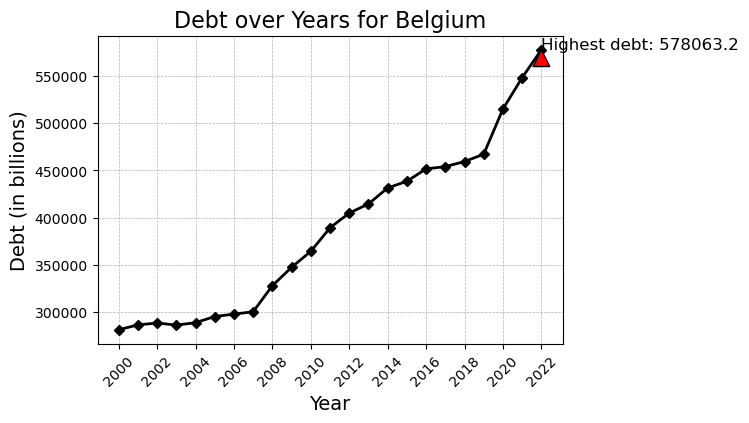

In [24]:
# Filter the data frame to only include data for Belgium
debt_belgium = debt_long.loc['Belgium',:]

# i reset the index because having countries as index messes with plotting
debt_belgium = debt_belgium.reset_index()

# Converting 'year' from string to numeric otherwise the code wont work
debt_belgium['year'] = pd.to_numeric(debt_belgium['year'], errors='coerce')

# plotting
debt_belgium.plot(x='year', y='debt', legend=False, color='black', linestyle='solid', linewidth=2, marker='D', markersize=5, figsize=(6, 4))
plt.xticks(np.arange(2000, 2023, 2), rotation=45)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Debt (in billions)', fontsize=14)
plt.title('Debt over Years for Belgium', fontsize=16)

# Add annotation for the maximum debt value
max_debt_year = debt_belgium['year'][debt_belgium['debt'].idxmax()]
max_debt_value = debt_belgium['debt'].max()
plt.annotate(f'Highest debt: {max_debt_value}', xy=(max_debt_year, max_debt_value), xytext=(max_debt_year, max_debt_value + 5),
             arrowprops=dict(facecolor='red', shrink=0.05), fontsize=12)

plt.show()